In [1]:
# General Overview of the Plan
"""
This is the Dynamic Transportation Factor Laboratory, where instead of parts we will be manufacturing Sharpe!
"""

'\nThis is the Dynamic Transportation Factor Laboratory, where instead of parts we will be manufacturing Sharpe!\n'

In [2]:
# Welcome to Japeshwar Singh's project, but please call me Jay :)
# This moves up a folder to access the juicy .py data
import sys
import os
print("Path:", os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('..'))

Path: C:\Users\japes\airline_factor_lab


In [3]:
# The Classics
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt
import models as md
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok = True)
print("data.py found:", os.path.exists('../data.py'))

data.py found: True


In [4]:
# Starting Data
stocks_returns, macro_returns, prices = dt.load_data()
print(f"Shape: {stocks_returns.shape}")
stocks_returns.head()

Stocks: 20 tickers
Macro columns: ['SPY', 'IYT', 'Brent', 'VIX']
Dates: 2336 trading days
Range: 2017-04-07 -> 2026-07-30
Shape: (2336, 20)


Ticker,DAL,UAL,AAL,LUV,ALK,JBLU,UNP,CSX,NSC,CP,CNI,UPS,FDX,JBHT,ODFL,KNX,SAIA,SNDR,CHRW,EXPD
Date,,,,,,,,,,,,,,,,,,,,
2017-04-07,-0.001991,0.009355,0.002155,0.021498,-0.002911,0.009046,-0.000374,-0.005886,0.000173,-0.000932,-0.006655,-0.015875,-0.001736,-0.012764,-0.008374,0.008190,-0.009174,0.000000,-0.007236,-0.012473
2017-04-10,-0.004438,0.008989,0.012124,-0.005884,-0.001459,0.007084,0.005497,0.005257,-0.003544,0.018546,0.016219,0.013529,0.000562,0.023224,0.014668,0.087081,0.025030,0.016184,0.006712,0.007147
2017-04-11,0.007091,-0.011390,0.037338,0.015374,-0.002249,0.013555,-0.000093,-0.009906,-0.002341,0.000392,-0.008482,-0.006316,-0.014251,-0.017421,-0.006056,-0.036634,-0.013575,-0.032634,-0.006448,-0.003567
2017-04-12,-0.005313,-0.011092,0.000683,0.008140,-0.002028,-0.015910,-0.019140,-0.017306,-0.030221,-0.014220,-0.008146,-0.014478,-0.035226,-0.015955,-0.022890,-0.066331,-0.037127,0.014342,-0.012754,-0.004836
2017-04-13,-0.022902,-0.012374,-0.013974,-0.021855,-0.026632,-0.022419,-0.007511,0.000431,-0.001880,-0.005385,-0.006427,-0.004712,-0.013945,-0.011377,-0.017952,-0.011227,-0.016687,0.001054,-0.004423,-0.006304


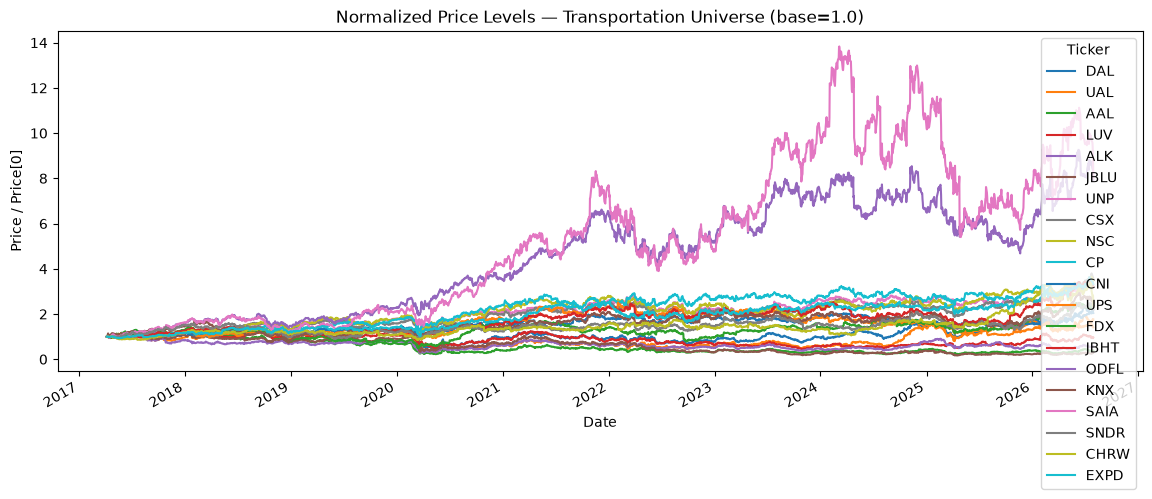

In [5]:
(prices[dt.stocks].dropna() /
 prices[dt.stocks].dropna().iloc[0]).plot(figsize = (14,5), title = "Normalized Price Levels — Transportation Universe (base=1.0)")
plt.ylabel("Price / Price[0]")
plt.show()

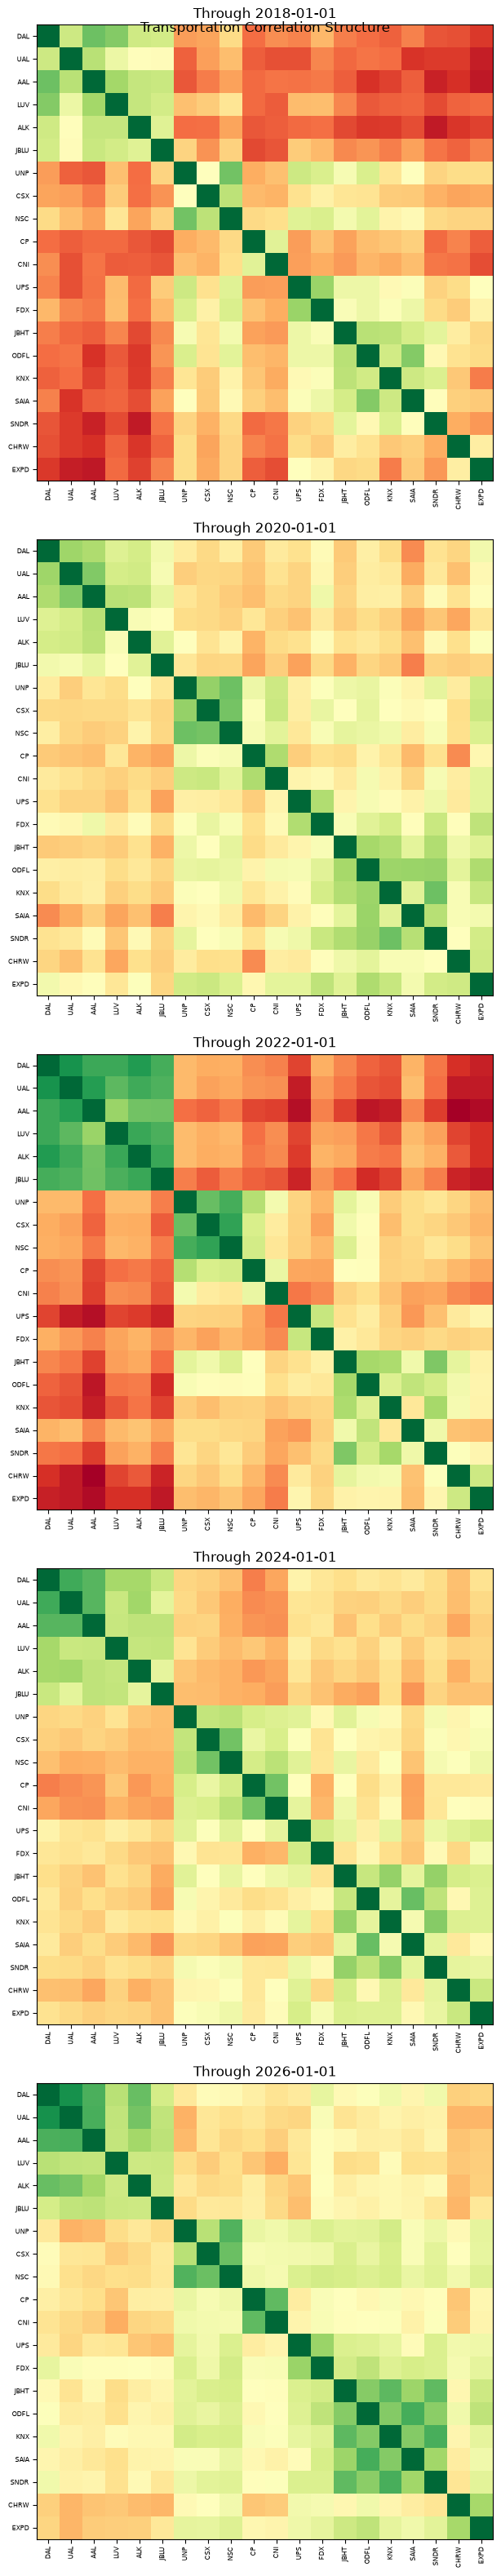

In [6]:
fig, axes = plt.subplots(5, 1, figsize = (32,32))
axes = axes.flatten()

dates = [
    '2018-01-01',
    '2020-01-01',
    '2022-01-01',
    '2024-01-01',
    '2026-01-01'
]

for ax, d in zip(axes, dates):
    subset = stocks_returns.loc[stocks_returns.index <= d].tail(252)
    corr = subset.corr()

    im = ax.imshow(corr,
                   cmap = 'RdYlGn',
                   vmin = 0,
                   vmax = 1)

    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns,
                       rotation = 90,
                       fontsize = 6)

    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns,
                       fontsize = 6)

    ax.set_title(f"Through {d}")

plt.suptitle("Transportation Correlation Structure")
plt.tight_layout()
plt.show()

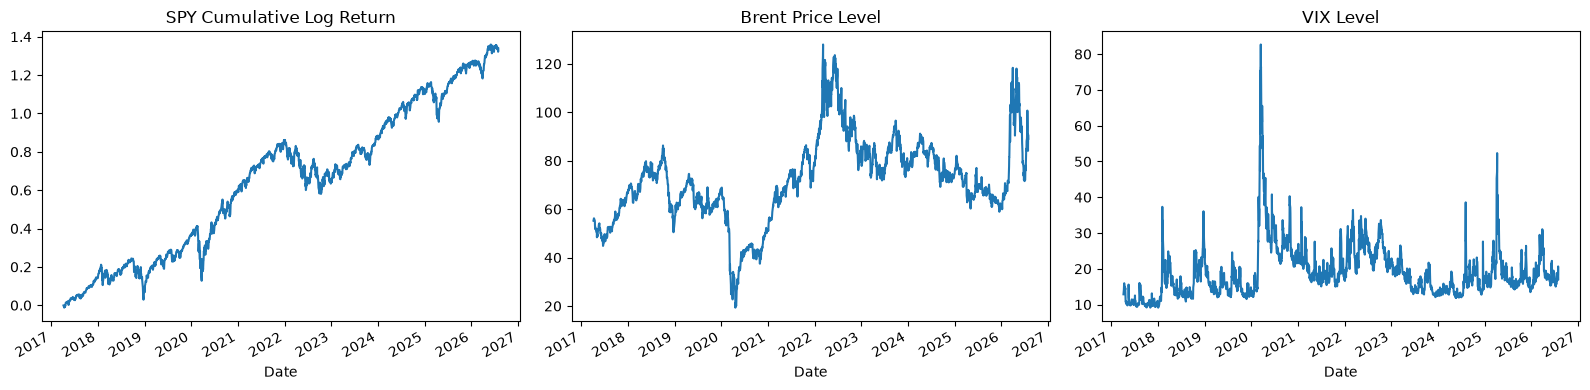

In [7]:
fig, axes = plt.subplots(1, 3, figsize = (16, 4))

macro_returns['SPY'].cumsum().plot(ax = axes[0], title = 'SPY Cumulative Log Return')
macro_returns['Brent'].plot(ax = axes[1], title = 'Brent Price Level')
macro_returns['VIX'].plot(ax = axes[2], title = 'VIX Level')

plt.tight_layout()
plt.show()

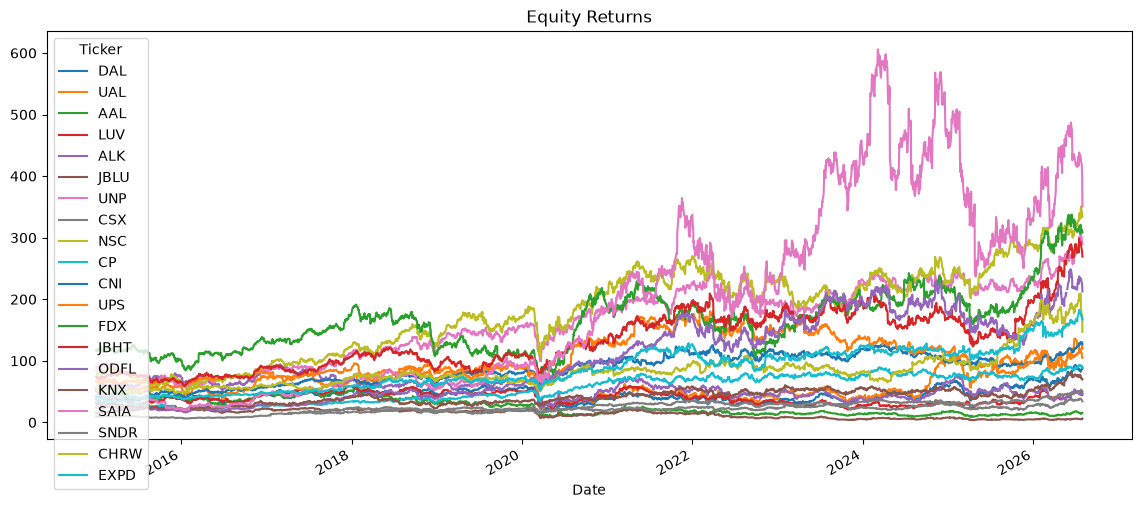

In [8]:
# Price Charts
prices[['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU', 'UNP', 'CSX', 'NSC', 'CP', 'CNI', 'UPS', 'FDX', 'JBHT', 'ODFL', 'KNX', 'SAIA', 'SNDR', 'CHRW', 'EXPD']].plot(figsize = (14,6),title = "Equity Returns")
plt.show()

<Axes: title={'center': 'Rolling Volatility'}, xlabel='Date'>

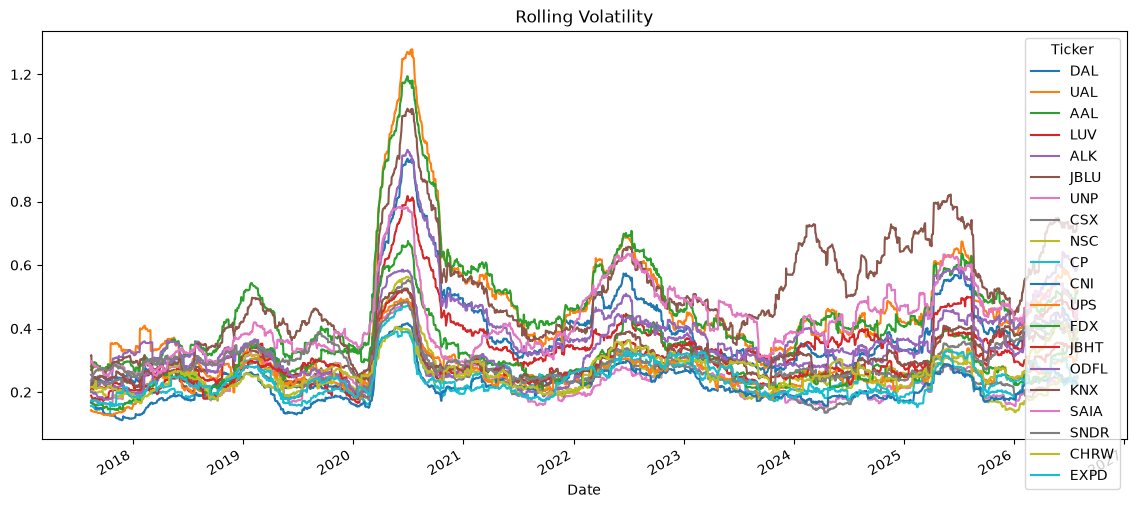

In [9]:
# Rolling Volatility
rolling_vol = stocks_returns.rolling(90).std() * np.sqrt(252)
rolling_vol.plot(figsize = (14,6), title = "Rolling Volatility")

In [10]:
# Thanks for your time, allow me to take you to the next Exhibit (02_Models.ipynb)!